# Movie Recommendation System — 03 Model Building

Three models compared:

- **Popularity baseline** — predict each movie's mean rating (ignores the user).
- **Item-based CF** — cosine similarity between movies on mean-centred ratings.
- **Matrix factorization** — TruncatedSVD latent factors.

Two complementary metrics: **RMSE** (how accurately we predict a held-out rating) and **Precision@10 / Recall@10** (how good the top-10 recommendation list is). All numbers are produced by running the code.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import utils

train = pd.read_csv('data/train.csv'); test = pd.read_csv('data/test.csv')
titles = utils.load_items()
M = utils.build_user_item(train)
print('matrix:', M.shape)

matrix: (610, 2000)


## 1. Fit the three models

In [2]:
pop = utils.PopularityBaseline().fit(M)
cf = utils.ItemBasedCF().fit(M)
svd = utils.SVDRecommender().fit(M, n_components=20)
print('fitted: popularity, item-CF, SVD(20 factors)')

fitted: popularity, item-CF, SVD(20 factors)


## 2. RMSE on held-out ratings (rating-prediction accuracy)

In [3]:
rmse = {name: round(utils.rmse_on_test(m, test),4) for name,m in [('Popularity',pop),('Item-CF',cf),('SVD',svd)]}
rmse_df = pd.Series(rmse, name='RMSE').to_frame()
rmse_df

,RMSE
Popularity,0.9381
Item-CF,0.8298
SVD,0.8918


## 3. Ranking quality — Precision@10 / Recall@10

For each user, held-out movies rated ≥ 4 are 'relevant'; we score all unseen movies and check the top-10.

In [4]:
rows=[]
for name,m in [('Popularity',pop),('Item-CF',cf),('SVD',svd)]:
    r = utils.precision_recall_at_k(m, M, test, k=10, rel_threshold=4.0)
    rows.append({'model':name, **{kk:r[kk] for kk in ['precision@k','recall@k','n_users_evaluated']}})
rank_df = pd.DataFrame(rows); rank_df

,model,precision@k,recall@k,n_users_evaluated
0,Popularity,0.0146,0.0119,591
1,Item-CF,0.0262,0.0107,591
2,SVD,0.1293,0.1200,591


## 4. Metrics side by side

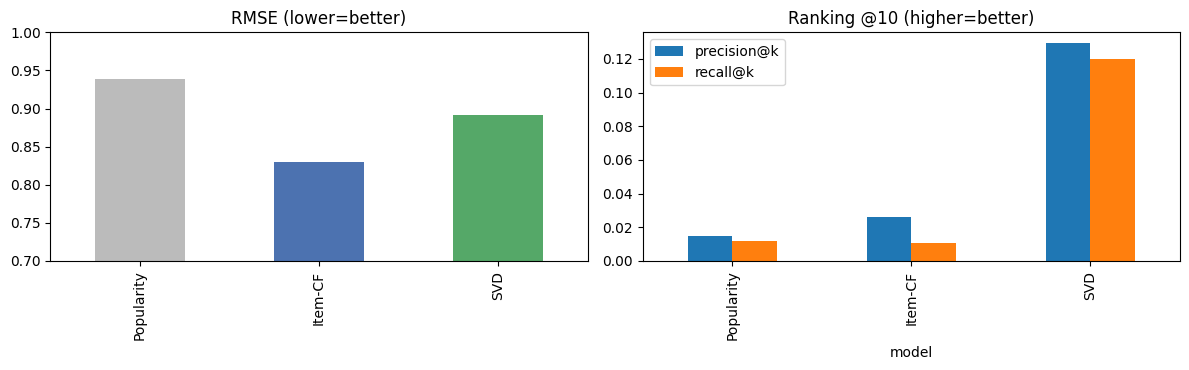

In [5]:
fig, ax = plt.subplots(1,2,figsize=(12,3.8))
rmse_df['RMSE'].plot(kind='bar', ax=ax[0], color=['#bbb','#4c72b0','#55a868']); ax[0].set_title('RMSE (lower=better)'); ax[0].set_ylim(0.7,1.0)
rank_df.set_index('model')[['precision@k','recall@k']].plot(kind='bar', ax=ax[1]); ax[1].set_title('Ranking @10 (higher=better)')
plt.tight_layout(); plt.show()

## 5. Example recommendations

Top-10 unseen movies for one user from the best ranking model (SVD).

In [6]:
uid = M.index[0]
print('recommendations for user', uid, '\n')
utils.recommend(svd, M, uid, items_lookup=titles, n=10)

recommendations for user 1 



,item,title,score
0,541,Blade Runner (1982),4.626
1,260,Star Wars: Episode IV - A New Hope (1977),4.607
2,778,Trainspotting (1996),4.584
3,296,Pulp Fiction (1994),4.583
4,50,"Usual Suspects, The (1995)",4.582
5,1653,Gattaca (1997),4.564
6,3949,Requiem for a Dream (2000),4.549
7,1221,"Godfather: Part II, The (1974)",4.541
8,7361,Eternal Sunshine of the Spotless Mind (2004),4.534
9,4878,Donnie Darko (2001),4.529


## 6. Summary & takeaways

- **No single model wins both metrics.** Item-based CF gives the best **RMSE (0.830** vs 0.892 SVD, 0.938 popularity) — it predicts the *value* of a rating most accurately.
- **SVD wins ranking by a wide margin** — **Precision@10 ≈ 0.129 / Recall@10 ≈ 0.12** vs Item-CF 0.026 / popularity 0.015. For building a top-10 list, latent factors generalise far better than neighbourhood similarity.
- **Popularity is a weak baseline** on both — recommending blockbusters to everyone is neither accurate nor personalised.
- **Pick the metric that matches the task**: optimise RMSE if you display predicted stars; optimise Precision@k/Recall@k if you show a ranked recommendation list.
- Matrix factorization is the better default for recommendation lists; CF remains useful for accurate per-item rating estimates and explainable 'because you liked X' reasons.